In [1]:
import gc
import torch

# 清理之前可能存在的残留显存占用
gc.collect()
torch.cuda.empty_cache()

# 启用 PyTorch 显存管理优化
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, HeteroConv, MessagePassing
from torch_geometric.utils import negative_sampling
import torch_geometric.transforms as T
from torch_geometric.datasets import Yelp
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

import scipy.io as sio
from torch_geometric.data import HeteroData

def load_local_yelpchi(path='data/YelpChi/raw/YelpChi.mat'):
    # 1. 加载 mat 文件
    mat = sio.loadmat(path)
    
    # 2. 提取数据
    # x: 节点特征, y: 标签, net_rur/rtr/rsr: 邻接矩阵
    features = torch.FloatTensor(mat['features'].todense())
    labels = torch.LongTensor(mat['label'].flatten())
    
    # 定义异质图对象
    data = HeteroData()
    
    # 3. 添加节点（核心节点类型为 'review'）
    data['review'].x = features
    data['review'].y = labels
    
    # 4. 添加异质关系 (YelpChi 包含三种关系)
    # RUR: Review-User-Review, RTR: Review-Tax-Review, RSR: Review-Star-Review
    # 这里将 .mat 中的稀疏矩阵转为 edge_index
    for rel_name in ['net_rur', 'net_rtr', 'net_rsr']:
        adj = mat[rel_name].tocoo()
        row = torch.from_numpy(adj.row).to(torch.long)
        col = torch.from_numpy(adj.col).to(torch.long)
        edge_index = torch.stack([row, col], dim=0)
        
        # 命名格式: (源节点, 关系名, 目标节点)
        data['review', rel_name, 'review'].edge_index = edge_index
        
    return data


In [ ]:
import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128      
    proj_dim = 256       
    hops = 2             
    epochs = 150         
    soft_end = 50        
    lr_decay_epoch = 50 
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.55 
    lambda_max = 1       
    link_weight = 0.5      
    weight_decay = 1e-4    

# --- SubgraphEnhancer ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        # 增加标签嵌入层：out_size 是 40，+1 是为了给 Masked/Unknown 预留位
        self.label_emb = nn.Embedding(out_size + 1, hidden_size * 8)
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.ln1 = nn.LayerNorm(hidden_size * 8)
        self.gat2 = GATConv(hidden_size * 8, hidden_size, heads=8, dropout=0.5)
        self.ln2 = nn.LayerNorm(hidden_size * 8)
        self.sampler_net = BilinearSampler(in_dim=hidden_size * 8, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(hidden_size * 8, hidden_size * 8)
        self.res_lin = nn.Linear(in_size, hidden_size * 8)
        
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear((hidden_size * 8) * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size * 8, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[row]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, col, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        """
        y_label: 输入的标签特征。
        - 训练时：是经过 Mask 处理的标签（部分可见，部分为 40/未知）。
        - 测试时：通过循环推理（Iterative Inference）或全 0/全未知初始化。
        """
        # 1. 标签嵌入融合
        # 将原始特征 x 与标签嵌入 y_label 进行融合，作为语义发现的起点
        # 这里的 y_label 应该是预先通过 self.label_emb(labels) 得到的嵌入
        x_fused = x + self.res_lin(x) + y_label  # 也可以使用 torch.cat
        
        # 2. 语义发现：现在 h1 和 h_base 包含了标签先验
        h1 = F.elu(self.ln1(self.gat1(x_fused, edge_index)))
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.ln2(h_base) + self.res_lin(x)) # 残差保持原始特征流
        
        # 3. 递归采样决策：
        # 采样器现在会根据“文本语义 + 邻居标签”双重证据计算 weights
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        # 4. 逻辑增强：
        h_enhanced = h_base
        for _ in range(self.hops):
            # 这里的增强过程会受到 weights 的控制
            # 如果 weights 发现边两端标签不一致，它会自动降低其贡献
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg) 
        
        # 5. 输出
        logits = self.classifier(h_enhanced)
        
        # 链路预测：使用包含标签信息的增强特征
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 模块四：数据加载
# ==========================================
dataset_name = 'ogbn-arxiv'
dataset = PygNodePropPredDataset(name=dataset_name, root='data', transform=T.ToUndirected())
data = dataset[0] # 保持在 CPU

split_idx = dataset.get_idx_split()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(
    data,
    num_neighbors=[8, 5], 
    batch_size=Config.batch_size,
    input_nodes=split_idx['train'],
    shuffle=True,
    num_workers=4,          
    persistent_workers=True
)

# 初始化模型（此时主进程还没碰显卡，直到下面的 .to(device)）
model = NeuralRecursiveSystem(dataset.num_features, hidden_size=Config.hidden_dim, out_size=dataset.num_classes, hops=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')

# ==========================================
# 模块五：Mini-batch 训练逻辑
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch = 0
    
    phys_node_counts, phys_edge_counts = [], []
    logic_node_counts, logic_edge_counts = [], []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    
    if epoch <= Config.soft_end:
        curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1)
    else:
        curr_lambda = Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        
        phys_node_counts.append(batch.num_nodes)
        phys_edge_counts.append(batch.edge_index.size(1))

        optimizer.zero_grad()
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, batch_target_mask, hard=use_hard
        )

        edge_mask = (weights > 0.5)
        logic_edge_count = edge_mask.sum().item()
        logic_nodes = torch.unique(batch.edge_index[:, edge_mask]).size(0)
        logic_edge_counts.append(logic_edge_count)
        logic_node_counts.append(logic_nodes)

        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_row, neg_col = neg_edge_index
        neg_edge_feat = torch.cat([h_enhanced[neg_row], h_enhanced[neg_col]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg))) * Config.link_weight
        
        current_sp = weights.mean()
        loss_sparse = F.mse_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        
        total_loss = loss_clf + loss_link + curr_lambda * loss_sparse
        if current_sp < 0.05: total_loss += (0.1 - current_sp) * 20
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss_epoch += total_loss.item()

    avg_p_nodes, avg_p_edges = np.mean(phys_node_counts), np.mean(phys_edge_counts)
    avg_l_nodes, avg_l_edges = np.mean(logic_node_counts), np.mean(logic_edge_counts)
    pruned_rate = (1 - avg_l_edges / avg_p_edges) * 100 if avg_p_edges > 0 else 0
    
    print(f"\n[Epoch {epoch:03d}] Pattern Summary:")
    print(f"  > Physical Context: Nodes {avg_p_nodes:.1f}, Edges {avg_p_edges:.1f}")
    print(f"  > Logical Backbone: Nodes {avg_l_nodes:.1f}, Edges {avg_l_edges:.1f} (Pruned: {pruned_rate:.1f}%)")
    
    return total_loss_epoch / len(train_loader), current_sp.item(), curr_lambda

# ==========================================
# 运行实验
# ==========================================
best_valid_acc = 0.0

# 评估数据只在需要 evaluate 的时候才搬运。

for epoch in range(1, Config.epochs + 1):
    avg_loss, last_sp, c_lam = train_minibatch(epoch, Config.epochs, 1.0, 0.1)
    
    if epoch % 5 == 0: 
        model.eval()
        with torch.no_grad():
            #### 【关键】：评估时临时搬运
            eval_data = data.to(device)
            full_mask = torch.ones(eval_data.num_nodes, dtype=torch.bool, device=device)
            lp, _, _, _ = model(eval_data.x, eval_data.edge_index, full_mask, hard=True)
            y_pred = lp.argmax(dim=-1, keepdim=True)
            
            train_acc = evaluator.eval({'y_true': eval_data.y[split_idx['train']], 'y_pred': y_pred[split_idx['train']]})['acc']
            valid_acc = evaluator.eval({'y_true': eval_data.y[split_idx['valid']], 'y_pred': y_pred[split_idx['valid']]})['acc']
            test_acc = evaluator.eval({'y_true': eval_data.y[split_idx['test']], 'y_pred': y_pred[split_idx['test']]})['acc']
            
            if valid_acc > best_valid_acc:
                best_valid_acc = valid_acc
                torch.save(model.state_dict(), 'best_arxiv_minibatch.pt')
                print(f"[*] New Best! Valid Acc: {valid_acc:.4f}")

            print(f"Ep: {epoch:03d} | Loss: {avg_loss:.4f} | Sp: {last_sp:.4f} | Val: {valid_acc:.4f} | Test: {test_acc:.4f}")
            
            # 评估完后，建议将 eval_data 移出显存或手动清理，防止显存溢出
            del eval_data
            torch.cuda.empty_cache()

/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.pro


[Epoch 001] Pattern Summary:
  > Physical Context: Nodes 14845.0, Edges 21629.8
  > Logical Backbone: Nodes 2355.7, Edges 4619.9 (Pruned: 78.6%)

[Epoch 002] Pattern Summary:
  > Physical Context: Nodes 14825.8, Edges 21615.4
  > Logical Backbone: Nodes 2365.3, Edges 4664.5 (Pruned: 78.4%)

[Epoch 003] Pattern Summary:
  > Physical Context: Nodes 14827.3, Edges 21617.1
  > Logical Backbone: Nodes 2368.7, Edges 4671.0 (Pruned: 78.4%)

[Epoch 004] Pattern Summary:
  > Physical Context: Nodes 14839.8, Edges 21623.3
  > Logical Backbone: Nodes 2365.6, Edges 4661.3 (Pruned: 78.4%)

[Epoch 005] Pattern Summary:
  > Physical Context: Nodes 14849.6, Edges 21634.7
  > Logical Backbone: Nodes 2368.9, Edges 4668.0 (Pruned: 78.4%)
[*] New Best! Valid Acc: 0.6972
Ep: 005 | Loss: 1.1491 | Sp: 0.2148 | Val: 0.6972 | Test: 0.6800

[Epoch 006] Pattern Summary:
  > Physical Context: Nodes 14825.6, Edges 21605.3
  > Logical Backbone: Nodes 2364.3, Edges 4662.4 (Pruned: 78.4%)

[Epoch 007] Pattern Summar

/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.pro

Starting Training: Label Reuse + Recursive Denoising...
      Ep: 004 | Clf_Loss: 1.0620 | Link_Loss: 0.1585 | Pruned: 78.4%
[*] NEW BEST Ep: 005 | Total:1.1835 | Val:0.6987 | Test:0.6823 | Pruned:78.4%
      Ep: 009 | Clf_Loss: 0.9960 | Link_Loss: 0.1381 | Pruned: 78.4%
[ ] Ep: 010 | Total:1.1278 | Val:0.6917 | Test:0.6685 | Pruned:78.4%
      Ep: 014 | Clf_Loss: 0.9537 | Link_Loss: 0.1272 | Pruned: 78.5%
[*] NEW BEST Ep: 015 | Total:1.0923 | Val:0.7133 | Test:0.7065 | Pruned:78.4%
      Ep: 019 | Clf_Loss: 0.9275 | Link_Loss: 0.1214 | Pruned: 78.4%
[ ] Ep: 020 | Total:1.0748 | Val:0.7034 | Test:0.6796 | Pruned:78.4%
      Ep: 024 | Clf_Loss: 0.9035 | Link_Loss: 0.1165 | Pruned: 78.4%
[ ] Ep: 025 | Total:1.0652 | Val:0.7014 | Test:0.6807 | Pruned:78.4%
      Ep: 029 | Clf_Loss: 0.8827 | Link_Loss: 0.1129 | Pruned: 78.5%
[*] NEW BEST Ep: 030 | Total:1.0536 | Val:0.7165 | Test:0.7083 | Pruned:78.4%
      Ep: 034 | Clf_Loss: 0.8666 | Link_Loss: 0.1107 | Pruned: 78.5%
[ ] Ep: 035 | Total:

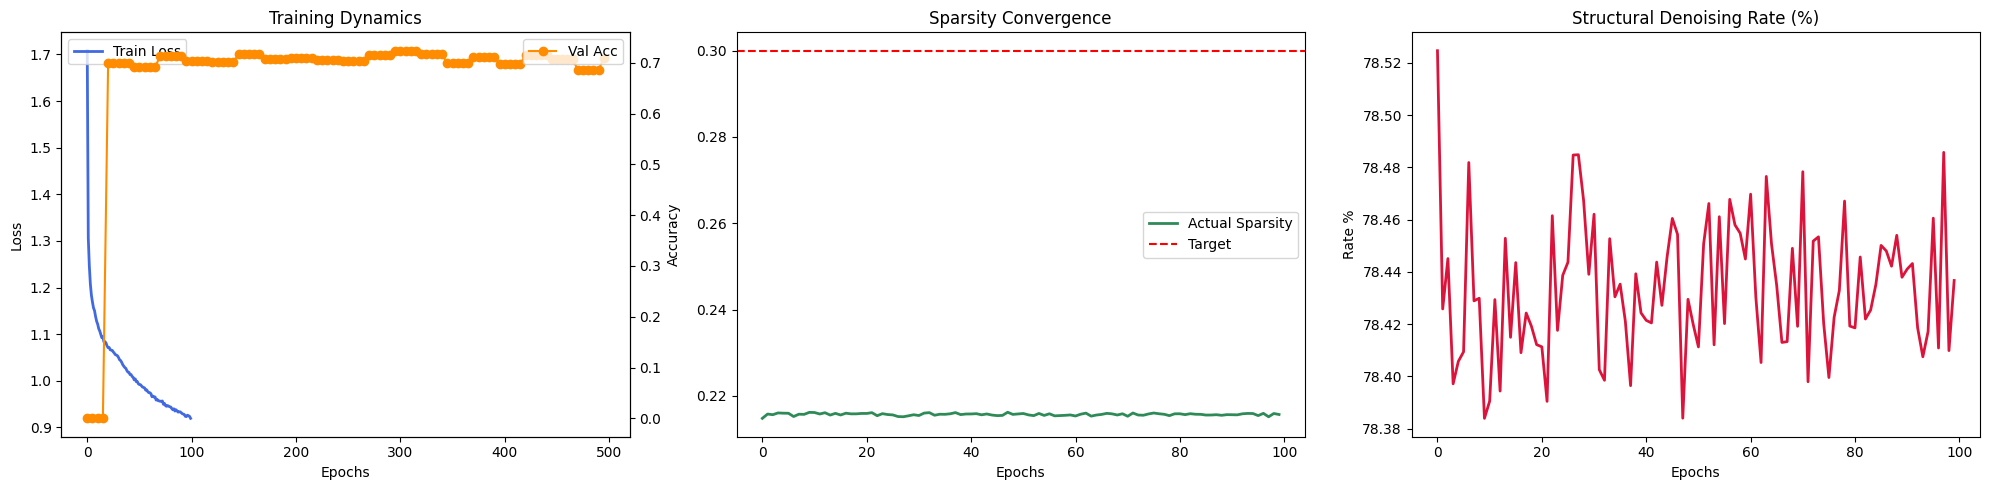

In [ ]:
# 标签重用

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 100         
    soft_end = 30        
    lr_decay_epoch = 40 
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.30 
    lambda_max = 0.05       
    link_weight = 0.8      
    weight_decay = 1e-4    

# --- SubgraphEnhancer (Local-Softmax) ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# 修正后的 NeuralRecursiveSystem
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        # 保持 hidden_size * 8 = 1024
        self.total_hidden = hidden_size * 8
        
        # 标签嵌入层
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        # 语义编码器
        self.gat1 = GATConv(in_size, hidden_size, heads=8, dropout=0.6)
        self.ln1 = nn.LayerNorm(self.total_hidden)
        
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.6)
        self.ln2 = nn.LayerNorm(self.total_hidden)
        
        # 采样器与增强器
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        
        # 残差投影层，确保所有项都能对齐到 total_hidden
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            torch.nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[row]
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, col, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):

        # 只有对齐后的 x_proj (1024维) 才能和 y_emb (1024维) 相加
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        
        # 融合：原始投影 + 标签先验
        x_fused = x_proj + y_emb 
        
        # 语义发现
        h1 = F.elu(self.ln1(self.gat1(x, edge_index))) # 第一层 GAT 输入还是原始 x (128维)
        
        # 第二层残差：h_base 结合了第一层语义和初始特征投影
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.ln2(h_base) + x_proj) 
        
        # 递归采样
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        # 模式增强
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = h_enhanced + F.elu(msg) 
            
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights

# ==========================================
# 数据加载
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data', transform=T.ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(
    data, num_neighbors=[10, 8], batch_size=Config.batch_size,
    input_nodes=split_idx['train'], shuffle=True, num_workers=4, persistent_workers=True
)

model = NeuralRecursiveSystem(dataset.num_features, hidden_size=Config.hidden_dim, out_size=dataset.num_classes, hops=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')

# ==========================================
# 训练逻辑
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch = 0
    total_clf_loss = 0
    total_link_loss = 0
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        # 统计规模
        total_phys_edges += batch.edge_index.size(1)
        # 【修改】
        total_logic_edges += weights.sum().item() # 使用软权重的累加值来观察
        #total_logic_edges += (weights > 0.5).sum().item()
        all_sp.append(weights.mean().item())

        # 细分 Loss 计算
        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        diff = weights.mean() - Config.target_sparsity
        loss_sparse = torch.abs(diff) # L1 惩罚
        
        # 总损失
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    # 计算平均值
    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate

# ==========================================
# 可视化工具函数
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Loss & Accuracy
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    # 2. Sparsity
    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    # 3. Pruned Rate
    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    
    plt.tight_layout(); plt.show()

# ==========================================
# 运行主循环 (细分指标看板版)
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0

print(f"Starting Training: Label Reuse + Recursive Denoising...")

for epoch in range(1, Config.epochs + 1):
    # 1. 训练并获取细分 Loss
    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.1)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    if epoch % 5 == 0: 
        model.eval()
        with torch.no_grad():
            eval_data = data.to(device)
            y_eval = eval_data.y.squeeze().clone()
            y_eval[split_idx['valid']] = dataset.num_classes
            y_eval[split_idx['test']] = dataset.num_classes
            
            full_mask = torch.ones(eval_data.num_nodes, dtype=torch.bool, device=device)
            lp, _, _, _ = model(eval_data.x, eval_data.edge_index, y_eval, full_mask, hard=True)
            y_pred = lp.argmax(dim=-1, keepdim=True)
            
            valid_acc = evaluator.eval({'y_true': eval_data.y[split_idx['valid']], 'y_pred': y_pred[split_idx['valid']]})['acc']
            test_acc = evaluator.eval({'y_true': eval_data.y[split_idx['test']], 'y_pred': y_pred[split_idx['test']]})['acc']
            
            history['val_acc'].append(valid_acc)
            history['test_acc'].append(test_acc)

            if valid_acc > best_valid_acc:
                best_valid_acc = valid_acc
                torch.save(model.state_dict(), 'best_arxiv_final.pt')
                status = "[*] NEW BEST"
            else:
                status = "[ ]"

            print(f"\n{status} Ep: {epoch:03d} | Total:{avg_loss:.4f} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | Pruned:{p_rate:.1f}%")
            del eval_data; torch.cuda.empty_cache()
    else:
        # --- 非评估轮次的细分看板 ---
        # 实时打印分类 Loss 和 链路 Loss
        print(f"      Ep: {epoch:03d} | Clf_Loss: {avg_clf:.4f} | Link_Loss: {avg_link:.4f} | Pruned: {p_rate:.1f}%", end='\r')
        
        # 填充历史记录保持绘图对齐
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)


# 最终展示结果
plot_training_history(history)

In [ ]:
# 标签重用  修改参数 修改mse—L1

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 100         
    soft_end = 50        
    lr_decay_epoch = 60 
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.40 
    lambda_max = 2.0       
    link_weight = 0.5     
    weight_decay = 5e-4    


# --- SubgraphEnhancer (Local-Softmax) ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) 
        return torch.sigmoid(score)

# ==========================================
# 强化后的 NeuralRecursiveSystem (包含完整逻辑)
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        
        # 标签嵌入层
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        # 语义编码器 + BatchNorm
        self.gat1 = GATConv(in_size, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        # 采样器与增强器
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    # 【补全缺失的方法】
    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        
        # 计算双线性分数
        scores = self.sampler_net(h[row], h[col])
        final_weights = torch.zeros(num_edges, device=edge_index.device)
        active_nodes = start_mask.float() 
        
        for h_step in range(self.hops):
            active_edges_mask = active_nodes[row]
            # Gumbel-Softmax 采样
            sampling_logits = torch.stack([1 - scores, scores], dim=-1).clamp(min=1e-9).log()
            sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
            
            current_step_weights = sampling_mask * active_edges_mask
            final_weights = torch.max(final_weights, current_step_weights)
            
            # 更新激活节点用于下一跳
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, col, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float() 
            
        return final_weights

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        # 1. 基础投影与标签融入
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        
        # 1. 初始融合： GAT 第一层就能感知到邻居的标签
        x_fused = x_proj + y_emb 
        
        # 2. 语义发现 
        h1 = self.gat1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb)
        
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        
        # 3. 递归采样
        weights = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        # 4. 模式增强 (加入 BN)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
            
        logits = self.classifier(h_enhanced)
        
        # 链路预测逻辑
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights


# ==========================================
# 数据加载
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data', transform=T.ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(
    data, num_neighbors=[15, 10], batch_size=Config.batch_size,
    input_nodes=split_idx['train'], shuffle=True, num_workers=4, persistent_workers=True
)

model = NeuralRecursiveSystem(dataset.num_features, hidden_size=Config.hidden_dim, out_size=dataset.num_classes, hops=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')

# ==========================================
# 训练逻辑
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch = 0
    total_clf_loss = 0
    total_link_loss = 0
    total_phys_edges, total_logic_edges = 0, 0
    all_sp = []

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau
    curr_lambda = 0.1 + (epoch/Config.soft_end) * (Config.lambda_max - 0.1) if epoch <= Config.soft_end else Config.lambda_max

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        # 统计规模
        total_phys_edges += batch.edge_index.size(1)
        total_logic_edges += (weights > 0.5).sum().item()
        all_sp.append(weights.mean().item())

        # 细分 Loss 计算
        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_sparse = F.mse_loss(weights.mean(), torch.tensor(Config.target_sparsity, device=device))
        
        # 总损失
        total_loss = loss_clf + Config.link_weight * loss_link + curr_lambda * loss_sparse
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    # 计算平均值
    avg_loss = total_loss_epoch / len(train_loader)
    avg_clf = total_clf_loss / len(train_loader)
    avg_link = total_link_loss / len(train_loader)
    avg_sp = np.mean(all_sp)
    p_rate = (1 - total_logic_edges / total_phys_edges) * 100
    
    return avg_loss, avg_clf, avg_link, avg_sp, p_rate

# ==========================================
# 可视化工具函数
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Loss & Accuracy
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    # 2. Sparsity
    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    # 3. Pruned Rate
    axes[2].plot(history['pruned_rate'], color='crimson', linewidth=2)
    axes[2].set_title("Structural Denoising Rate (%)"); axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Rate %')
    
    plt.tight_layout(); plt.show()

# ==========================================
# 运行主循环 (细分指标看板版)
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': [], 'pruned_rate': []}
best_valid_acc = 0.0

print(f"Starting Training: Label Reuse + Recursive Denoising...")

for epoch in range(1, Config.epochs + 1):
    # 1. 训练并获取细分 Loss
    avg_loss, avg_clf, avg_link, avg_sp, p_rate = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    history['pruned_rate'].append(p_rate)
    
    if epoch % 5 == 0: 
        model.eval()
        with torch.no_grad():
            eval_data = data.to(device)
            y_eval = eval_data.y.squeeze().clone()
            y_eval[split_idx['valid']] = dataset.num_classes
            y_eval[split_idx['test']] = dataset.num_classes
            
            full_mask = torch.ones(eval_data.num_nodes, dtype=torch.bool, device=device)
            lp, _, _, _ = model(eval_data.x, eval_data.edge_index, y_eval, full_mask, hard=True)
            y_pred = lp.argmax(dim=-1, keepdim=True)
            
            valid_acc = evaluator.eval({'y_true': eval_data.y[split_idx['valid']], 'y_pred': y_pred[split_idx['valid']]})['acc']
            test_acc = evaluator.eval({'y_true': eval_data.y[split_idx['test']], 'y_pred': y_pred[split_idx['test']]})['acc']
            
            history['val_acc'].append(valid_acc)
            history['test_acc'].append(test_acc)

            if valid_acc > best_valid_acc:
                best_valid_acc = valid_acc
                torch.save(model.state_dict(), 'best_arxiv_final.pt')
                status = "[*] NEW BEST"
            else:
                status = "[ ]"

            print(f"\n{status} Ep: {epoch:03d} | Total:{avg_loss:.4f} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | Pruned:{p_rate:.1f}%")
            del eval_data; torch.cuda.empty_cache()
    else:
        # --- 非评估轮次的细分看板 ---
        # 实时打印分类 Loss 和 链路 Loss
        print(f"      Ep: {epoch:03d} | Clf_Loss: {avg_clf:.4f} | Link_Loss: {avg_link:.4f} | Pruned: {p_rate:.1f}%", end='\r')
        
        # 填充历史记录保持绘图对齐
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)


# 最终展示结果
plot_training_history(history)

/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.pro

Starting Training: Label Reuse + Recursive Denoising...
      Ep: 004 | Clf_Loss: 0.8908 | Link_Loss: 0.1260 | Pruned: 79.4%
[*] NEW BEST Ep: 005 | Total:0.9550 | Val:0.7117 | Test:0.6948 | Pruned:80.1%
      Ep: 009 | Clf_Loss: 0.8427 | Link_Loss: 0.1067 | Pruned: 78.7%
[ ] Ep: 010 | Total:0.9045 | Val:0.7094 | Test:0.6926 | Pruned:78.6%
      Ep: 014 | Clf_Loss: 0.8120 | Link_Loss: 0.0984 | Pruned: 78.4%
[ ] Ep: 015 | Total:0.8777 | Val:0.7013 | Test:0.6782 | Pruned:78.5%


KeyboardInterrupt: 

In [2]:
# 标签重用  修改参数 修改mse—L1

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax 
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# global参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 100         
    soft_end = 50        
    lr_decay_epoch = 60 
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.30 
    lambda_max = 0.05       
    link_weight = 0.05     
    weight_decay = 5e-4    


# --- SubgraphEnhancer (Local-Softmax) ---
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        # 初始偏置 3.0 代表初始留边概率约为 95%
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
        
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        # 计算原始分数
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        # 【物理截断】：防止梯度爆炸导致数值溢出，保护递归链
        return torch.clamp(score, min=-10.0, max=10.0)

# ==========================================
# 强化后的 NeuralRecursiveSystem (针对有向图路径修复版)
# ==========================================
class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden * 2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    # 【修复重点】：递归采样逻辑
    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index # row: 邻居(source), col: 当前中心节点(target)
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        
        # 1. 稳定性 Logits (使用之前推荐的能量模型)
        logits_raw = self.sampler_net(h[row], h[col])
        
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        
        # 2. 采样掩码
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        
        # 3. 【修复】：有向图激活追踪逻辑
        # 在 NeighborLoader 中，子图是逆着箭头采样的。
        # 我们必须从 col (中心) 激活 row (邻居)，实现 Target -> Source 的递归。
        active_nodes = start_mask.float() 
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        for h_step in range(self.hops):
            # 激活边：如果这条边的“目标(col)”是被激活的中心，这条边才有资格留存
            edge_active_mask = active_nodes[col] 
            
            current_step_weights = sampling_mask * edge_active_mask
            # 这里的 max 保证了多跳路径重叠时保留最强信号
            final_weights = torch.max(final_weights, current_step_weights)
            
            # 传递激活：将激活状态从 col (当前) 传给 row (上游参考文献节点)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = (new_active_nodes > 1e-5).float()
            
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        x_fused = x_proj + y_emb 
        
        # 【修复】：确保 gat1 先计算，避免变量未定义报错
        h1 = self.gat1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb) 
        
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        
        # 3. 递归采样
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        
        # 4. 模式增强
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
            
        logits = self.classifier(h_enhanced)
        
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        
        # 【修复】：返回分离出的 logits_raw 用于 debug
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights, logits_raw.detach()

# ==========================================
# 训练逻辑加固
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0
    all_sp = []

    # 1. 动态权重调整
    if epoch <= 10:
        curr_lambda = 0.0          
        curr_link_weight = 0.02    # 【建议】：初期大幅降低链路权重，防止干扰采样器
    else:
        progress = min(1.0, (epoch - 10) / (Config.soft_end - 10))
        curr_lambda = 0.01 + progress * (Config.lambda_max - 0.01)
        curr_link_weight = Config.link_weight

    use_hard = True if epoch > Config.soft_end else False
    curr_tau = max(end_tau, start_tau - (epoch / total_epochs) * (start_tau - end_tau))
    model.tau = curr_tau

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        # 【修复】：增加 debug_logits 接收
        log_probs, link_probs_pos, h_enhanced, weights, debug_logits = model(
            batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard
        )

        current_sp = weights.mean()
        all_sp.append(current_sp.item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_base_sp = F.l1_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        
        # 【修复】：保险丝逻辑。惩罚系数增加到 100.0。
        # 只要 Sparsity 低于 0.63 (0.7 * 0.9)，产生巨大梯度拉回
        collapse_threshold = Config.target_sparsity * 0.9 
        penalty = 100.0 * F.relu(collapse_threshold - current_sp) 

        total_loss = loss_clf + curr_link_weight * loss_link + curr_lambda * loss_base_sp + penalty
        
        total_loss.backward()

        # 【修复】：DEBUG 监控 (仅在第 1 轮查看能量分布)
        if epoch == 1 and len(all_sp) % 10 == 0:
            print(f"DEBUG: Logits Mean: {debug_logits.mean().item():.4f} | Prob: {torch.sigmoid(debug_logits).mean().item():.4f} | SP: {current_sp.item():.4f}", end='\r')

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_epoch += total_loss.item()
        total_clf_loss += loss_clf.item()
        total_link_loss += loss_link.item()

    avg_sp = np.mean(all_sp)
    return total_loss_epoch/len(train_loader), total_clf_loss/len(train_loader), total_link_loss/len(train_loader), avg_sp

# ==========================================
# 数据加载 (保留有向性修改)
# ==========================================

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data')
data = dataset[0]

# 为有向图添加自环 (Self-loops)
from torch_geometric.utils import add_self_loops
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index

split_idx = dataset.get_idx_split()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 【关键修改】增加采样数
# 因为是有向图，采样只能沿着引用的反向进行，范围变小，需增加采样宽度
train_loader = NeighborLoader(
    data, 
    num_neighbors=[20, 15],  # 增加采样宽度以捕捉更丰富的有向拓扑
    batch_size=Config.batch_size,
    input_nodes=split_idx['train'], 
    shuffle=True, 
    num_workers=4, 
    persistent_workers=True
)

model = NeuralRecursiveSystem(dataset.num_features, hidden_size=Config.hidden_dim, out_size=dataset.num_classes, hops=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')


# ==========================================
# 可视化工具函数
# ==========================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Loss & Accuracy
    ax1 = axes[0]
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(range(0, len(history['val_acc'])*5, 5), history['val_acc'], label='Val Acc', color='darkorange', marker='o')
    ax2.set_ylabel('Accuracy')
    ax1.set_title("Training Dynamics"); ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

    # 2. Sparsity
    axes[1].plot(history['sparsity'], label='Actual Sparsity', color='seagreen', linewidth=2)
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle='--', label='Target')
    axes[1].set_title("Sparsity Convergence"); axes[1].set_xlabel('Epochs'); axes[1].legend()

    # 3. 测试集 Acc 走势
    axes[2].plot(history['test_acc'], color='crimson')
    axes[2].set_title("Test Accuracy Trend")

    plt.tight_layout(); plt.show()

# ==========================================
# 强化后的运行主循环 
# ==========================================
history = {'train_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': []}
best_valid_acc = 0.0

# 【新增】早停配置
patience = 6          # 允许连续 6 次评估（即 30 个 epoch）不上升
stagnant_epochs = 0   # 计数器
early_stop_triggered = False

# 【新增】学习率调度器：在第 30, 60 轮分别将 LR 减半
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.5)

print(f"Starting Training: Label Reuse + Recursive Denoising...")

for epoch in range(1, Config.epochs + 1):
    # 1. 训练并获取细分 Loss
    avg_loss, avg_clf, avg_link, avg_sp = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    
    # 【新增】更新学习率
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_loss)
    history['sparsity'].append(avg_sp)
    
    if epoch % 5 == 0: 
        model.eval()
        with torch.no_grad():
            eval_data = data.to(device)
            y_eval = eval_data.y.squeeze().clone()
            y_eval[split_idx['valid']] = dataset.num_classes
            y_eval[split_idx['test']] = dataset.num_classes
            
            full_mask = torch.ones(eval_data.num_nodes, dtype=torch.bool, device=device)

            lp, _, _, _, _ = model(eval_data.x, eval_data.edge_index, y_eval, full_mask, hard=True)
            y_pred = lp.argmax(dim=-1, keepdim=True)
            
            valid_acc = evaluator.eval({'y_true': eval_data.y[split_idx['valid']], 'y_pred': y_pred[split_idx['valid']]})['acc']
            test_acc = evaluator.eval({'y_true': eval_data.y[split_idx['test']], 'y_pred': y_pred[split_idx['test']]})['acc']
            
            history['val_acc'].append(valid_acc)
            history['test_acc'].append(test_acc)

            # 【新增】早停与最佳模型保存逻辑
            if valid_acc > best_valid_acc:
                best_valid_acc = valid_acc
                stagnant_epochs = 0  # 重置计数器
                torch.save(model.state_dict(), 'best_arxiv_final.pt')
                status = "[*] NEW BEST"
            else:
                stagnant_epochs += 1 # 累计不上升次数
                status = "[ ]"
            print(f"\n{status} Ep: {epoch:03d} | LR: {current_lr:.6f} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | Sparsity:{avg_sp:.4f}")
            
            # 【新增】早停触发判定
            if stagnant_epochs >= patience:
                print(f"\n[Early Stop] Triggered! No improvement for {patience * 5} epochs.")
                early_stop_triggered = True
                break
                
            del eval_data; torch.cuda.empty_cache()
    else:
        # 非评估轮次的看板，增加 LR 显示
        print(f"      Ep: {epoch:03d} | LR: {current_lr:.6f} | Clf_Loss: {avg_clf:.4f} | Sparsity: {avg_sp:.4f}", end='\r')
        last_val = history['val_acc'][-1] if len(history['val_acc']) > 0 else 0
        last_test = history['test_acc'][-1] if len(history['test_acc']) > 0 else 0
        history['val_acc'].append(last_val)
        history['test_acc'].append(last_test)

if early_stop_triggered:
    # 早停后加载最佳权重，确保绘图和后续分析使用的是最优模型
    model.load_state_dict(torch.load('best_arxiv_final.pt'))
    print("Loaded best model weights for final evaluation.")

# 最终展示结果
plot_training_history(history)

/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.pro

Starting Training: Label Reuse + Recursive Denoising...
      Ep: 004 | LR: 0.001000 | Clf_Loss: 1.1567 | Sparsity: 0.9493
[*] NEW BEST Ep: 005 | LR: 0.001000 | Val:0.5343 | Test:0.5018 | Sparsity:0.9252
      Ep: 009 | LR: 0.001000 | Clf_Loss: 1.0852 | Sparsity: 0.9040
[*] NEW BEST Ep: 010 | LR: 0.001000 | Val:0.5792 | Test:0.5457 | Sparsity:0.9078
      Ep: 014 | LR: 0.001000 | Clf_Loss: 1.0379 | Sparsity: 0.6374
[ ] Ep: 015 | LR: 0.001000 | Val:0.5533 | Test:0.5117 | Sparsity:0.4986


KeyboardInterrupt: 

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...
      Ep: 004 | Clf_L: 0.9235 | Lnk_L: 0.2610 | SP: 0.4239
[*] NEW BEST Ep: 005 | Val:0.7321 | Test:0.7237 | SP:0.4307
      Ep: 009 | Clf_L: 0.8465 | Lnk_L: 0.2940 | SP: 0.6892
[*] NEW BEST Ep: 010 | Val:0.7466 | Test:0.7386 | SP:0.7425
      Ep: 014 | Clf_L: 0.8122 | Lnk_L: 0.1300 | SP: 0.3233
[ ] Ep: 015 | Val:0.7395 | Test:0.7278 | SP:0.3274
      Ep: 019 | Clf_L: 0.8015 | Lnk_L: 0.1233 | SP: 0.3129
[ ] Ep: 020 | Val:0.7404 | Test:0.7313 | SP:0.3138
      Ep: 024 | Clf_L: 0.7926 | Lnk_L: 0.1205 | SP: 0.3086
[ ] Ep: 025 | Val:0.7362 | Test:0.7222 | SP:0.3058
      Ep: 029 | Clf_L: 0.7840 | Lnk_L: 0.1205 | SP: 0.3042
[ ] Ep: 030 | Val:0.7426 | Test:0.7329 | SP:0.3056
      Ep: 034 | Clf_L: 0.7490 | Lnk_L: 0.1165 | SP: 0.3018
[ ] Ep: 035 | Val:0.7447 | Test:0.7371 | SP:0.3046
      Ep: 039 | Clf_L: 0.7418 | Lnk_L: 0.1178 | SP: 0.3018
[ ] Ep: 040 | Val:0.7393 | Test:0.7221 | SP:0.3031

[Early Stop] Triggered at e

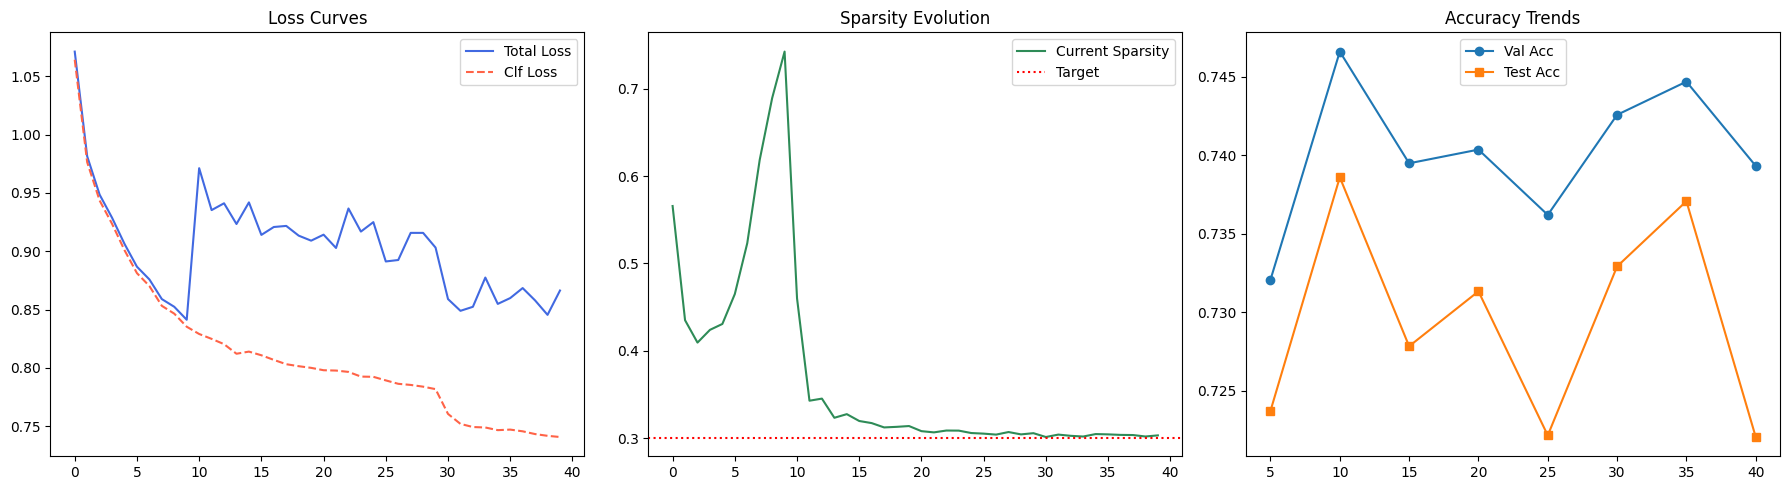

In [ ]:
# new 1.31 无向图 

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global 参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 150         
    soft_end = 50        
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.30  # 保留 30%，剪枝 70%
    lambda_max = 1.0       
    link_weight = 0.7      
    weight_decay = 5e-4    
    patience = 6            # 连续 6 次评估（30轮）不上升则早停

# ==========================================
# 2. 核心架构组件
# ==========================================
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
        
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = nn.Sequential(
            nn.Linear(self.total_hidden * 2, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        
        active_nodes = start_mask.float() 
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        for h_step in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
            
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        x_fused = x_proj + y_emb 
        h1 = self.gat1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb) 
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights, logits_raw.detach()

# ==========================================
# 3. 核心训练与推理函数
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0
    all_sp = []
    
    if epoch <= 10:
        curr_lambda, curr_link_weight = 0.0, 0.02
    else:
        progress = min(1.0, (epoch - 10) / (Config.soft_end - 10))
        curr_lambda = 0.01 + progress * (Config.lambda_max - 0.01)
        curr_link_weight = Config.link_weight

    use_hard = epoch > Config.soft_end
    curr_tau = max(0.2, start_tau - (epoch / total_epochs) * (start_tau - 0.2))
    model.tau = curr_tau

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights, _ = model(batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard)
        current_sp = weights.mean()
        all_sp.append(current_sp.item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_base_sp = F.l1_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        penalty = 100.0 * F.relu(Config.target_sparsity * 0.9 - current_sp) 

        total_loss = loss_clf + curr_link_weight * loss_link + curr_lambda * loss_base_sp + penalty
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        
        total_loss_epoch += total_loss.item(); total_clf_loss += loss_clf.item(); total_link_loss += loss_link.item()

    return total_loss_epoch/len(train_loader), total_clf_loss/len(train_loader), total_link_loss/len(train_loader), np.mean(all_sp)

@torch.no_grad()
def inference_minibatch(loader):
    model.eval()
    y_preds, y_trues = [], []
    for batch in loader:
        batch = batch.to(device)
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes # 严格隔离中心节点标签
        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        mask[:batch.batch_size] = True
        
        lp, _, _, _, _ = model(batch.x, batch.edge_index, y_input, mask, hard=True)
        y_preds.append(lp[:batch.batch_size].argmax(dim=-1).cpu())
        y_trues.append(batch.y[:batch.batch_size].cpu())
        
    y_pred = torch.cat(y_preds, dim=0).numpy().reshape(-1, 1)
    y_true = torch.cat(y_trues, dim=0).numpy().reshape(-1, 1)
    return evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Total Loss', color='royalblue')
    axes[0].plot(history['clf_loss'], label='Clf Loss', color='tomato', linestyle='--')
    axes[0].set_title("Loss Curves"); axes[0].legend()
    
    axes[1].plot(history['sparsity'], label='Current Sparsity', color='seagreen')
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle=':', label='Target')
    axes[1].set_title("Sparsity Evolution"); axes[1].legend()
    
    val_epochs = range(5, len(history['val_acc'])*5 + 1, 5)
    axes[2].plot(val_epochs, history['val_acc'], label='Val Acc', marker='o')
    axes[2].plot(val_epochs, history['test_acc'], label='Test Acc', marker='s')
    axes[2].set_title("Accuracy Trends"); axes[2].legend()
    plt.tight_layout(); plt.show()

# ==========================================
# 4. 数据加载与主循环 (Mini-batch 推理)
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data', transform=T.ToUndirected())
data = dataset[0]
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
split_idx = dataset.get_idx_split(); device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(data, num_neighbors=[20, 15], batch_size=Config.batch_size, input_nodes=split_idx['train'], shuffle=True)
# 推理用 Loader (看全邻居以保证评估准确性)
valid_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['valid'], shuffle=False)
test_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['test'], shuffle=False)

model = NeuralRecursiveSystem(dataset.num_features, Config.hidden_dim, dataset.num_classes).to(device)
sampler_params = list(model.sampler_net.parameters())
other_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]
optimizer = torch.optim.Adam([{'params': other_params, 'lr': Config.lr_init}, {'params': sampler_params, 'lr': Config.lr_init * 0.1}], weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.5)

history = {'train_loss': [], 'clf_loss': [], 'link_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': []}
best_valid_acc, stagnant_epochs = 0.0, 0

print(f"Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...")

for epoch in range(1, Config.epochs + 1):
    avg_loss, avg_clf, avg_link, avg_sp = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    scheduler.step()
    history['train_loss'].append(avg_loss); history['clf_loss'].append(avg_clf)
    history['link_loss'].append(avg_link); history['sparsity'].append(avg_sp)
    
    if epoch % 5 == 0: 
        # 调用 Mini-batch 推理
        valid_acc = inference_minibatch(valid_loader)
        test_acc = inference_minibatch(test_loader)
        history['val_acc'].append(valid_acc); history['test_acc'].append(test_acc)
        
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc; stagnant_epochs = 0
            torch.save(model.state_dict(), 'best_arxiv_final.pt'); status = "[*] NEW BEST"
        else:
            stagnant_epochs += 1; status = "[ ]"
            
        print(f"\n{status} Ep: {epoch:03d} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | SP:{avg_sp:.4f}")
        if stagnant_epochs >= Config.patience: 
            print(f"\n[Early Stop] Triggered at epoch {epoch}")
            break
        torch.cuda.empty_cache()
    else:
        print(f"      Ep: {epoch:03d} | Clf_L: {avg_clf:.4f} | Lnk_L: {avg_link:.4f} | SP: {avg_sp:.4f}", end='\r')

plot_training_history(history)

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...
      Ep: 004 | Clf_L: 0.9238 | Lnk_L: 0.2576 | SP: 0.4678
[*] NEW BEST Ep: 005 | Val:0.7414 | Test:0.7326 | SP:0.4405
      Ep: 009 | Clf_L: 0.8459 | Lnk_L: 0.2924 | SP: 0.6240
[*] NEW BEST Ep: 010 | Val:0.7420 | Test:0.7385 | SP:0.6894
      Ep: 014 | Clf_L: 0.8176 | Lnk_L: 0.1297 | SP: 0.3366
[ ] Ep: 015 | Val:0.7408 | Test:0.7315 | SP:0.3186
      Ep: 019 | Clf_L: 0.8009 | Lnk_L: 0.1231 | SP: 0.3136
[ ] Ep: 020 | Val:0.7330 | Test:0.7261 | SP:0.3102
      Ep: 024 | Clf_L: 0.7936 | Lnk_L: 0.1197 | SP: 0.3068
[ ] Ep: 025 | Val:0.7321 | Test:0.7252 | SP:0.3089
      Ep: 029 | Clf_L: 0.7843 | Lnk_L: 0.1190 | SP: 0.3048
[*] NEW BEST Ep: 030 | Val:0.7450 | Test:0.7389 | SP:0.3042
      Ep: 034 | Clf_L: 0.7498 | Lnk_L: 0.1160 | SP: 0.3038
[*] NEW BEST Ep: 035 | Val:0.7452 | Test:0.7306 | SP:0.3026
      Ep: 039 | Clf_L: 0.7437 | Lnk_L: 0.1171 | SP: 0.3021
[ ] Ep: 040 | Val:0.7430 | Test:0.7280 | SP:0.3027
      Ep: 

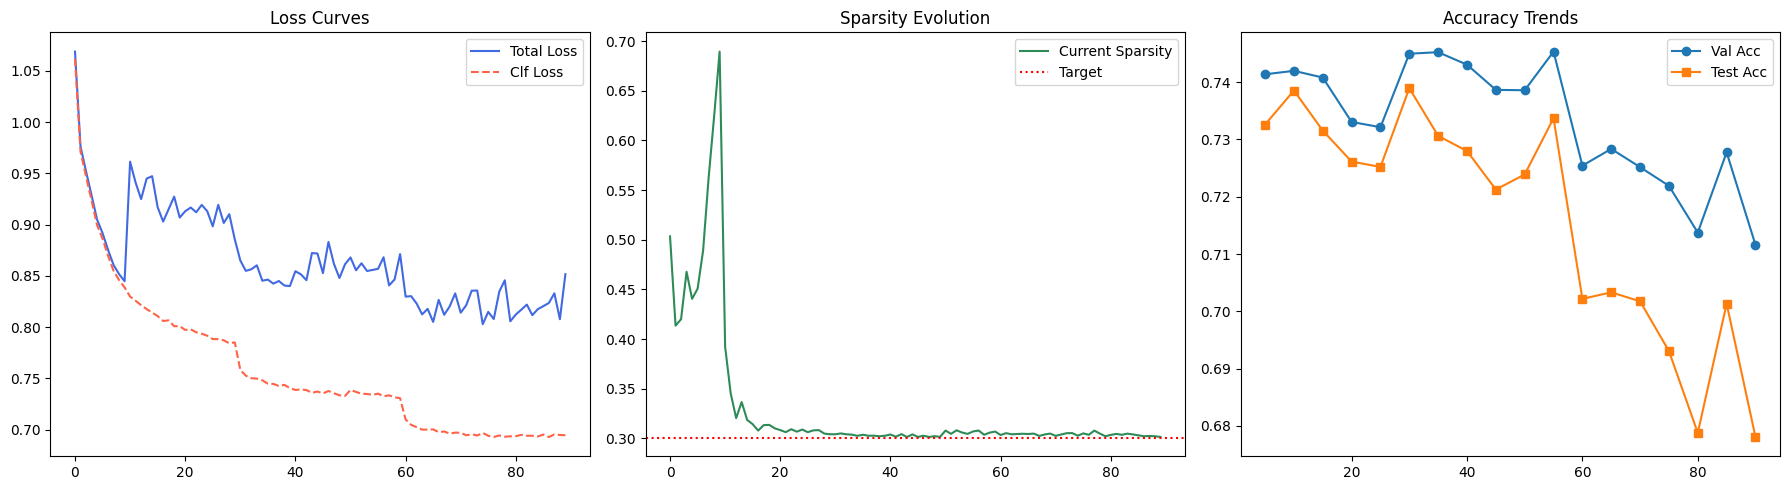

In [ ]:
# new 1.31 无向图 


import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global 参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 150         
    soft_end = 50        
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.30  
    lambda_max = 1.0       
    link_weight = 0.7      
    weight_decay = 5e-4    
    patience = 7            # 连续 6 次评估不上升则早停

# ==========================================
# 2. 核心架构组件
# ==========================================
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
        
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = nn.Sequential(
            nn.Linear(self.total_hidden * 2, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        
        active_nodes = start_mask.float() 
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        for h_step in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
            
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        x_fused = x_proj + y_emb 
        h1 = self.gat1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb) 
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights, logits_raw.detach()

# ==========================================
# 3. 核心训练与推理函数
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0
    all_sp = []
    
    if epoch <= 10:
        curr_lambda, curr_link_weight = 0.0, 0.02
    else:
        progress = min(1.0, (epoch - 10) / (Config.soft_end - 10))
        curr_lambda = 0.01 + progress * (Config.lambda_max - 0.01)
        curr_link_weight = Config.link_weight

    use_hard = epoch > Config.soft_end
    curr_tau = max(0.2, start_tau - (epoch / total_epochs) * (start_tau - 0.2))
    model.tau = curr_tau

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights, _ = model(batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard)
        current_sp = weights.mean()
        all_sp.append(current_sp.item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_base_sp = F.l1_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        penalty = 100.0 * F.relu(Config.target_sparsity * 0.9 - current_sp) 

        total_loss = loss_clf + curr_link_weight * loss_link + curr_lambda * loss_base_sp + penalty
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        
        total_loss_epoch += total_loss.item(); total_clf_loss += loss_clf.item(); total_link_loss += loss_link.item()

    return total_loss_epoch/len(train_loader), total_clf_loss/len(train_loader), total_link_loss/len(train_loader), np.mean(all_sp)

@torch.no_grad()
def inference_minibatch(loader):
    model.eval()
    y_preds, y_trues = [], []
    for batch in loader:
        batch = batch.to(device)
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes # 严格隔离中心节点标签
        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        mask[:batch.batch_size] = True
        
        lp, _, _, _, _ = model(batch.x, batch.edge_index, y_input, mask, hard=True)
        y_preds.append(lp[:batch.batch_size].argmax(dim=-1).cpu())
        y_trues.append(batch.y[:batch.batch_size].cpu())
        
    y_pred = torch.cat(y_preds, dim=0).numpy().reshape(-1, 1)
    y_true = torch.cat(y_trues, dim=0).numpy().reshape(-1, 1)
    return evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Total Loss', color='royalblue')
    axes[0].plot(history['clf_loss'], label='Clf Loss', color='tomato', linestyle='--')
    axes[0].set_title("Loss Curves"); axes[0].legend()
    
    axes[1].plot(history['sparsity'], label='Current Sparsity', color='seagreen')
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle=':', label='Target')
    axes[1].set_title("Sparsity Evolution"); axes[1].legend()
    
    val_epochs = range(5, len(history['val_acc'])*5 + 1, 5)
    axes[2].plot(val_epochs, history['val_acc'], label='Val Acc', marker='o')
    axes[2].plot(val_epochs, history['test_acc'], label='Test Acc', marker='s')
    axes[2].set_title("Accuracy Trends"); axes[2].legend()
    plt.tight_layout(); plt.show()




/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...
      Ep: 004 | Clf_L: 0.9227 | Lnk_L: 0.2561 | SP: 0.4266
[*] NEW BEST Ep: 005 | Val:0.7355 | Test:0.7253 | SP:0.4785
      Ep: 009 | Clf_L: 0.8487 | Lnk_L: 0.2931 | SP: 0.7056
[*] NEW BEST Ep: 010 | Val:0.7400 | Test:0.7212 | SP:0.7915
      Ep: 014 | Clf_L: 0.8160 | Lnk_L: 0.1423 | SP: 0.3344
[ ] Ep: 015 | Val:0.7335 | Test:0.7223 | SP:0.3252
      Ep: 019 | Clf_L: 0.8031 | Lnk_L: 0.1369 | SP: 0.3067
[ ] Ep: 020 | Val:0.7358 | Test:0.7178 | SP:0.3045
      Ep: 024 | Clf_L: 0.7924 | Lnk_L: 0.1362 | SP: 0.3066
[ ] Ep: 025 | Val:0.7343 | Test:0.7286 | SP:0.3056
      Ep: 029 | Clf_L: 0.7860 | Lnk_L: 0.1361 | SP: 0.3044
[ ] Ep: 030 | Val:0.7271 | Test:0.7146 | SP:0.3083
      Ep: 034 | Clf_L: 0.7516 | Lnk_L: 0.1346 | SP: 0.3038
[ ] Ep: 035 | Val:0.7309 | Test:0.7163 | SP:0.3040
      Ep: 039 | Clf_L: 0.7456 | Lnk_L: 0.1373 | SP: 0.3035
[*] NEW BEST Ep: 040 | Val:0.7424 | Test:0.7344 | SP:0.3019
      Ep: 044 | Clf

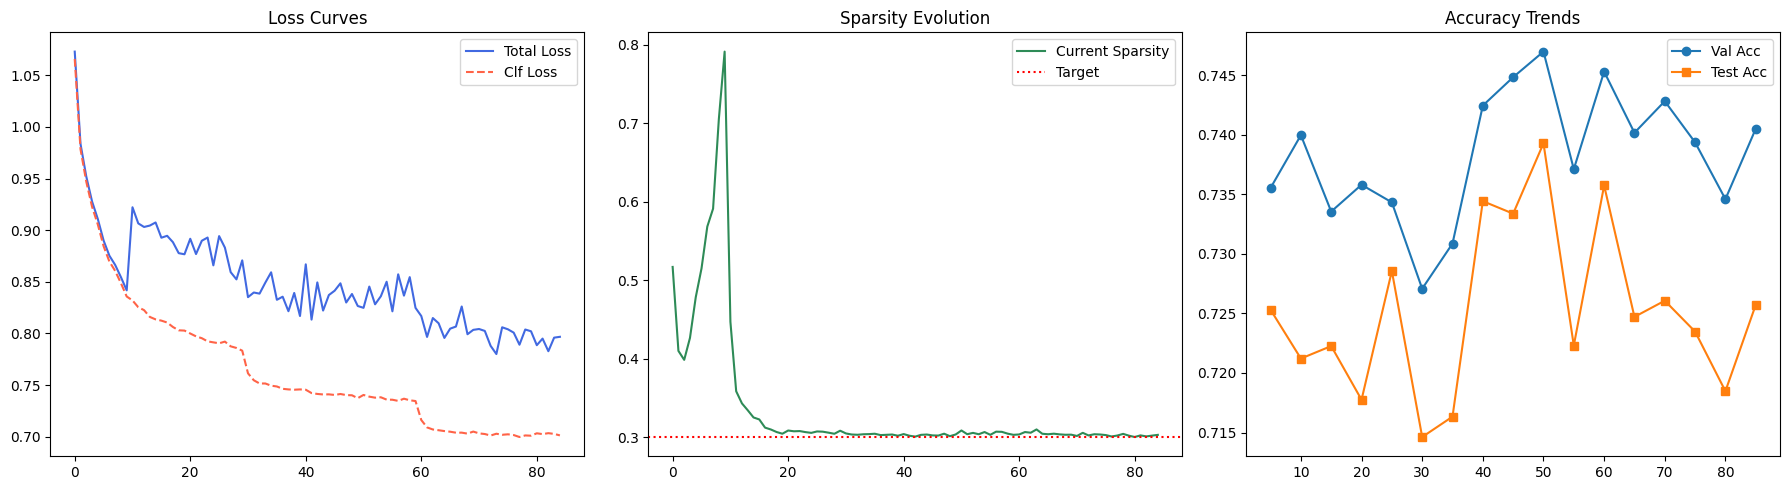

In [1]:
# new 1.31 无向图 


import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global 参数配置
# ==========================================
class Config:
    hidden_dim = 128     
    proj_dim = 256       
    hops = 2             
    epochs = 150         
    soft_end = 50        
    lr_init = 0.001      
    batch_size = 512    
    target_sparsity = 0.30  
    lambda_max = 1.0       
    link_weight = 0.4      
    weight_decay = 5e-4    
    patience = 7            # 连续 6 次评估不上升则早停

# ==========================================
# 2. 核心架构组件
# ==========================================
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
        
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = nn.Sequential(
            nn.Linear(self.total_hidden * 2, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        
        active_nodes = start_mask.float() 
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        for h_step in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
            
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        x_fused = x_proj + y_emb 
        h1 = self.gat1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb) 
        h_base = self.gat2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights, logits_raw.detach()

# ==========================================
# 3. 核心训练与推理函数
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0
    all_sp = []
    
    if epoch <= 10:
        curr_lambda, curr_link_weight = 0.0, 0.02
    else:
        progress = min(1.0, (epoch - 10) / (Config.soft_end - 10))
        curr_lambda = 0.01 + progress * (Config.lambda_max - 0.01)
        curr_link_weight = Config.link_weight

    use_hard = epoch > Config.soft_end
    curr_tau = max(0.2, start_tau - (epoch / total_epochs) * (start_tau - 0.2))
    model.tau = curr_tau

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights, _ = model(batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard)
        current_sp = weights.mean()
        all_sp.append(current_sp.item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_base_sp = F.l1_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        penalty = 100.0 * F.relu(Config.target_sparsity * 0.9 - current_sp) 

        total_loss = loss_clf + curr_link_weight * loss_link + curr_lambda * loss_base_sp + penalty
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        
        total_loss_epoch += total_loss.item(); total_clf_loss += loss_clf.item(); total_link_loss += loss_link.item()

    return total_loss_epoch/len(train_loader), total_clf_loss/len(train_loader), total_link_loss/len(train_loader), np.mean(all_sp)

@torch.no_grad()
def inference_minibatch(loader):
    model.eval()
    y_preds, y_trues = [], []
    for batch in loader:
        batch = batch.to(device)
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes # 严格隔离中心节点标签
        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        mask[:batch.batch_size] = True
        
        lp, _, _, _, _ = model(batch.x, batch.edge_index, y_input, mask, hard=True)
        y_preds.append(lp[:batch.batch_size].argmax(dim=-1).cpu())
        y_trues.append(batch.y[:batch.batch_size].cpu())
        
    y_pred = torch.cat(y_preds, dim=0).numpy().reshape(-1, 1)
    y_true = torch.cat(y_trues, dim=0).numpy().reshape(-1, 1)
    return evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Total Loss', color='royalblue')
    axes[0].plot(history['clf_loss'], label='Clf Loss', color='tomato', linestyle='--')
    axes[0].set_title("Loss Curves"); axes[0].legend()
    
    axes[1].plot(history['sparsity'], label='Current Sparsity', color='seagreen')
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle=':', label='Target')
    axes[1].set_title("Sparsity Evolution"); axes[1].legend()
    
    val_epochs = range(5, len(history['val_acc'])*5 + 1, 5)
    axes[2].plot(val_epochs, history['val_acc'], label='Val Acc', marker='o')
    axes[2].plot(val_epochs, history['test_acc'], label='Test Acc', marker='s')
    axes[2].set_title("Accuracy Trends"); axes[2].legend()
    plt.tight_layout(); plt.show()

# ==========================================
# 4. 数据加载与主循环 (Mini-batch 推理)
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data', transform=T.ToUndirected())
data = dataset[0]
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
split_idx = dataset.get_idx_split(); device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(data, num_neighbors=[20, 15], batch_size=Config.batch_size, input_nodes=split_idx['train'], shuffle=True)
# 推理用 Loader (看全邻居以保证评估准确性)
valid_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['valid'], shuffle=False)
test_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['test'], shuffle=False)

model = NeuralRecursiveSystem(dataset.num_features, Config.hidden_dim, dataset.num_classes).to(device)
sampler_params = list(model.sampler_net.parameters())
other_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]
optimizer = torch.optim.Adam([{'params': other_params, 'lr': Config.lr_init}, {'params': sampler_params, 'lr': Config.lr_init * 0.1}], weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.5)

history = {'train_loss': [], 'clf_loss': [], 'link_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': []}
best_valid_acc, stagnant_epochs = 0.0, 0

print(f"Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...")

for epoch in range(1, Config.epochs + 1):
    avg_loss, avg_clf, avg_link, avg_sp = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    scheduler.step()
    history['train_loss'].append(avg_loss); history['clf_loss'].append(avg_clf)
    history['link_loss'].append(avg_link); history['sparsity'].append(avg_sp)
    
    if epoch % 5 == 0: 
        # 调用 Mini-batch 推理
        valid_acc = inference_minibatch(valid_loader)
        test_acc = inference_minibatch(test_loader)
        history['val_acc'].append(valid_acc); history['test_acc'].append(test_acc)
        
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc; stagnant_epochs = 0
            torch.save(model.state_dict(), 'best_arxiv_final.pt'); status = "[*] NEW BEST"
        else:
            stagnant_epochs += 1; status = "[ ]"
            
        print(f"\n{status} Ep: {epoch:03d} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | SP:{avg_sp:.4f}")
        if stagnant_epochs >= Config.patience: 
            print(f"\n[Early Stop] Triggered at epoch {epoch}")
            break
        torch.cuda.empty_cache()
    else:
        print(f"      Ep: {epoch:03d} | Clf_L: {avg_clf:.4f} | Lnk_L: {avg_link:.4f} | SP: {avg_sp:.4f}", end='\r')

plot_training_history(history)

In [ ]:
# 2.8 GCN new

import os
import os.path as osp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, MessagePassing  # [修改] 引入 GCNConv
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global 参数配置
# ==========================================
class Config:
    hidden_dim = 128      
    proj_dim = 256        
    hops = 2              
    epochs = 150          
    soft_end = 50         
    lr_init = 0.001       
    batch_size = 512     
    target_sparsity = 0.30  
    lambda_max = 1.0        
    link_weight = 0.4       
    weight_decay = 5e-4    
    patience = 7            

# ==========================================
# 2. 核心架构组件
# ==========================================
class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)

    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
        
    def forward(self, h_i, h_j):
        z_i = self.proj(h_i)
        z_j = self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        # [修改] 将 GAT 改为 GCN
        # 维度设为 total_hidden (1024)，不再使用 heads 参数
        self.gcn1 = GCNConv(self.total_hidden, self.total_hidden)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gcn2 = GCNConv(self.total_hidden, self.total_hidden)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        
        self.link_predictor = nn.Sequential(
            nn.Linear(self.total_hidden * 2, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(self.total_hidden, hidden_size * 4),
            nn.BatchNorm1d(hidden_size * 4),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_size * 4, out_size)
        )
        self.hops = hops
        self.tau = tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        num_nodes = h.size(0)
        num_edges = edge_index.size(1)
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        
        active_nodes = start_mask.float() 
        final_weights = torch.zeros(num_edges, device=edge_index.device)

        for h_step in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(num_nodes, device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
            
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x) 
        y_emb = self.label_emb(y_label)
        x_fused = x_proj + y_emb 
        
        # [修改] 使用 GCN 层进行前向传播
        h1 = self.gcn1(x_fused, edge_index) 
        h1 = F.elu(self.bn1(h1) + y_emb) 
        h_base = self.gcn2(h1, edge_index)
        h_base = F.elu(self.bn2(h_base) + x_proj) 
        
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            msg = self.enhancer(h_enhanced, edge_index, weights)
            h_enhanced = F.elu(self.bn_enh(h_enhanced + msg)) 
        logits = self.classifier(h_enhanced)
        row, col = edge_index
        pos_edge_feat = torch.cat([h_enhanced[row], h_enhanced[col]], dim=-1)
        link_probs_pos = self.link_predictor(pos_edge_feat).squeeze()
        return F.log_softmax(logits, dim=1), link_probs_pos, h_enhanced, weights, logits_raw.detach()
    # ==========================================
# 3. 核心训练与推理函数
# ==========================================
def train_minibatch(epoch, total_epochs, start_tau, end_tau):
    model.train()
    total_loss_epoch, total_clf_loss, total_link_loss = 0, 0, 0
    all_sp = []
    
    if epoch <= 10:
        curr_lambda, curr_link_weight = 0.0, 0.02
    else:
        progress = min(1.0, (epoch - 10) / (Config.soft_end - 10))
        curr_lambda = 0.01 + progress * (Config.lambda_max - 0.01)
        curr_link_weight = Config.link_weight

    use_hard = epoch > Config.soft_end
    curr_tau = max(0.2, start_tau - (epoch / total_epochs) * (start_tau - 0.2))
    model.tau = curr_tau

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes 
        batch_target_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        batch_target_mask[:batch.batch_size] = True

        log_probs, link_probs_pos, h_enhanced, weights, _ = model(batch.x, batch.edge_index, y_input, batch_target_mask, hard=use_hard)
        current_sp = weights.mean()
        all_sp.append(current_sp.item())

        loss_clf = F.nll_loss(log_probs[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
        neg_edge_index = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
        neg_edge_feat = torch.cat([h_enhanced[neg_edge_index[0]], h_enhanced[neg_edge_index[1]]], dim=-1)
        link_probs_neg = model.link_predictor(neg_edge_feat).squeeze()
        loss_link = (F.binary_cross_entropy(link_probs_pos, torch.ones_like(link_probs_pos)) + \
                     F.binary_cross_entropy(link_probs_neg, torch.zeros_like(link_probs_neg)))
        
        loss_base_sp = F.l1_loss(current_sp, torch.tensor(Config.target_sparsity, device=device))
        penalty = 100.0 * F.relu(Config.target_sparsity * 0.9 - current_sp) 

        total_loss = loss_clf + curr_link_weight * loss_link + curr_lambda * loss_base_sp + penalty
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        
        total_loss_epoch += total_loss.item(); total_clf_loss += loss_clf.item(); total_link_loss += loss_link.item()

    return total_loss_epoch/len(train_loader), total_clf_loss/len(train_loader), total_link_loss/len(train_loader), np.mean(all_sp)

@torch.no_grad()
def inference_minibatch(loader):
    model.eval()
    y_preds, y_trues = [], []
    for batch in loader:
        batch = batch.to(device)
        y_input = batch.y.squeeze().clone()
        y_input[:batch.batch_size] = dataset.num_classes # 严格隔离中心节点标签
        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
        mask[:batch.batch_size] = True
        
        lp, _, _, _, _ = model(batch.x, batch.edge_index, y_input, mask, hard=True)
        y_preds.append(lp[:batch.batch_size].argmax(dim=-1).cpu())
        y_trues.append(batch.y[:batch.batch_size].cpu())
        
    y_pred = torch.cat(y_preds, dim=0).numpy().reshape(-1, 1)
    y_true = torch.cat(y_trues, dim=0).numpy().reshape(-1, 1)
    return evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Total Loss', color='royalblue')
    axes[0].plot(history['clf_loss'], label='Clf Loss', color='tomato', linestyle='--')
    axes[0].set_title("Loss Curves"); axes[0].legend()
    
    axes[1].plot(history['sparsity'], label='Current Sparsity', color='seagreen')
    axes[1].axhline(y=Config.target_sparsity, color='red', linestyle=':', label='Target')
    axes[1].set_title("Sparsity Evolution"); axes[1].legend()
    
    val_epochs = range(5, len(history['val_acc'])*5 + 1, 5)
    axes[2].plot(val_epochs, history['val_acc'], label='Val Acc', marker='o')
    axes[2].plot(val_epochs, history['test_acc'], label='Test Acc', marker='s')
    axes[2].set_title("Accuracy Trends"); axes[2].legend()
    plt.tight_layout(); plt.show()

# ==========================================
# 4. 数据加载与主循环 (Mini-batch 推理)
# ==========================================
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='data', transform=T.ToUndirected())
data = dataset[0]
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
split_idx = dataset.get_idx_split(); device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = NeighborLoader(data, num_neighbors=[20, 15], batch_size=Config.batch_size, input_nodes=split_idx['train'], shuffle=True)
# 推理用 Loader (看全邻居以保证评估准确性)
valid_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['valid'], shuffle=False)
test_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, input_nodes=split_idx['test'], shuffle=False)

model = NeuralRecursiveSystem(dataset.num_features, Config.hidden_dim, dataset.num_classes).to(device)
sampler_params = list(model.sampler_net.parameters())
other_params = [p for n, p in model.named_parameters() if 'sampler_net' not in n]
optimizer = torch.optim.Adam([{'params': other_params, 'lr': Config.lr_init}, {'params': sampler_params, 'lr': Config.lr_init * 0.1}], weight_decay=Config.weight_decay)
evaluator = Evaluator(name='ogbn-arxiv')
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.5)

history = {'train_loss': [], 'clf_loss': [], 'link_loss': [], 'val_acc': [], 'test_acc': [], 'sparsity': []}
best_valid_acc, stagnant_epochs = 0.0, 0

print(f"Starting Training: Label Reuse + Recursive Denoising (Mini-batch Eval)...")

for epoch in range(1, Config.epochs + 1):
    avg_loss, avg_clf, avg_link, avg_sp = train_minibatch(epoch, Config.epochs, 1.0, 0.2)
    scheduler.step()
    history['train_loss'].append(avg_loss); history['clf_loss'].append(avg_clf)
    history['link_loss'].append(avg_link); history['sparsity'].append(avg_sp)
    
    if epoch % 5 == 0: 
        # 调用 Mini-batch 推理
        valid_acc = inference_minibatch(valid_loader)
        test_acc = inference_minibatch(test_loader)
        history['val_acc'].append(valid_acc); history['test_acc'].append(test_acc)
        
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc; stagnant_epochs = 0
            torch.save(model.state_dict(), 'best_arxiv_final.pt'); status = "[*] NEW BEST"
        else:
            stagnant_epochs += 1; status = "[ ]"
            
        print(f"\n{status} Ep: {epoch:03d} | Val:{valid_acc:.4f} | Test:{test_acc:.4f} | SP:{avg_sp:.4f}")
        if stagnant_epochs >= Config.patience: 
            print(f"\n[Early Stop] Triggered at epoch {epoch}")
            break
        torch.cuda.empty_cache()
    else:
        print(f"      Ep: {epoch:03d} | Clf_L: {avg_clf:.4f} | Lnk_L: {avg_link:.4f} | SP: {avg_sp:.4f}", end='\r')

plot_training_history(history)